# ANALYSIS OF BIBLIOGRAPHIC DATA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import plotly.express as px

# Helpers

In [2]:
def powerset_bit(iterable):
    s = list(iterable)
    return [subset for r in range(1, len(s) + 1)
            for subset in itertools.combinations(s, r)]
# Tests
powerset_bit("abc")

[('a',), ('b',), ('c',), ('a', 'b'), ('a', 'c'), ('b', 'c'), ('a', 'b', 'c')]

# Data access

In [3]:
path = "/Users/jlheller/home/Technical/repos/ModularitySurvey/axes/highly_relevant_axis_scores.csv"
FULL_DF = pd.read_csv(path)
SCORE_DF = FULL_DF[ ["trait_score", "network_score", "function_score"]]
SCORE_DF

,trait_score,network_score,function_score
0,0,90,30
1,0,10,80
2,0,90,0
3,0,80,40
4,0,70,30
...,...,...,...
204,0,30,50
205,0,10,100
206,0,20,70
207,60,20,30


# Coverage Plots

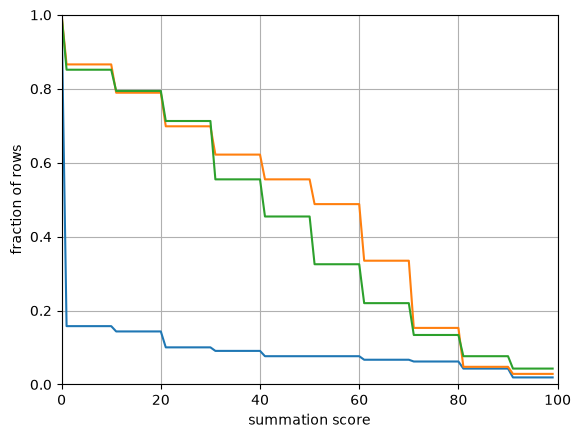

In [4]:
def plotCoverage(arr: np.ndarray):
    xv = []
    yv = []
    for x in range(100):
        xv.append(x)
        yv.append(np.sum(arr >= x) / len(arr))
    plt.plot(xv, yv)
    plt.xlim([0, 100])
    plt.ylim([0, 1])
    plt.xlabel("summation score")
    plt.ylabel("fraction of rows")
    plt.grid()

# Tests
plotCoverage(SCORE_DF["trait_score"])
plotCoverage(SCORE_DF["network_score"])
plotCoverage(SCORE_DF["function_score"])

In [5]:
def plotAll(is_sum: bool = True):
    plotCoverage(SCORE_DF["trait_score"])
    plotCoverage(SCORE_DF["network_score"])
    plotCoverage(SCORE_DF["function_score"])
    plotCoverage(np.maximum(SCORE_DF["trait_score"], SCORE_DF['network_score']))
    plotCoverage(np.maximum(SCORE_DF["trait_score"], SCORE_DF['function_score']))
    plotCoverage(np.maximum(SCORE_DF["function_score"], SCORE_DF['network_score']))
    if sum:
        vec = SCORE_DF['trait_score'] +  SCORE_DF["function_score"] + SCORE_DF['network_score']
    else:
        vec = np.maximum(SCORE_DF['trait_score'], SCORE_DF["function_score"])
        vec = np.maximum(vec, SCORE_DF['network_score'])
    plotCoverage(vec)
    _ = plt.legend(["T", "N", "F", "TN", "TF", "NF", "TNF"])

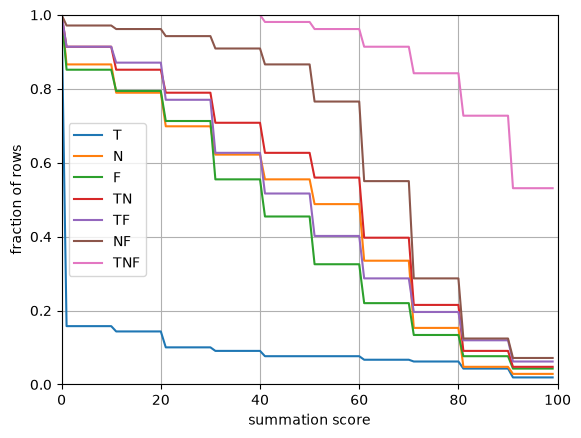

In [6]:
plotAll(is_sum = True)

# Correlation analysis

In [7]:
SCORE_DF.corr()

,trait_score,network_score,function_score
trait_score,1.000000,-0.350431,-0.320771
network_score,-0.350431,1.000000,-0.503380
function_score,-0.320771,-0.503380,1.000000


# 3D Plot

In [13]:
df = SCORE_DF.copy()

# Many papers share identical scores; a little jitter keeps points from hiding each other.
rng = np.random.default_rng(0)
for col in ["trait_score", "network_score", "function_score"]:
    df[col + "_j"] = df[col] + rng.uniform(-2, 2, len(df))

# Colour each paper by its highest-scoring axis.
axes = {"trait_score": "Traits", "network_score": "Networks", "function_score": "Functions"}
df["primary axis"] = df[list(axes)].idxmax(axis=1).map(axes)
df["size"] = df["trait_score"] + df["network_score"] + df["function_score"]

fig = px.scatter_3d(
    df,
    x="trait_score_j", y="network_score_j", z="function_score_j",
    color="primary axis",                     # categorical colour
    size=df["size"],           # marker size; +5 so zero scores stay visible
    size_max=14,
    opacity=0.8,
    #hover_name="paper title",                 # bold title on hover
    #hover_data={"DOI": True, "evolution_trajectory_score": True, "hierarchy_score": True,
    #            "trait_score_j": False, "network_score_j": False, "function_score_j": False},
    labels={"trait_score_j": "Traits", "network_score_j": "Networks", "function_score_j": "Functions"},
    title="Highly relevant papers on the three modularity axes (size = hierarchy score)",
)
fig.update_layout(scene=dict(xaxis_range=[-5, 105], yaxis_range=[-5, 105], zaxis_range=[-5, 105]))
fig.write_html("axis_scores_3d.html")   # or fig.show() in a notebook
#fig.show()